In [1]:
import Kea
from Kea.utils import plotting, data_reader
from Kea.simulator import fbm
from Kea.statistics import statistics_base, moments
from Kea.statistics.spectra import strfn_spectra, spectra_base, arevalo_spectra, per_spectra
from Kea.statistics.statfunc import strfn, statfunc_base, statfunc_mpi_naive
from Kea.fitting import fit_base

from Kea.api.sim_data import SimulationData, SimulationType

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt

import numpy as np

from scipy import fft

L = 2.*np.pi
D = 3
phys_dims = [L for _ in range(D)]

In [2]:
data = SimulationData(SimulationType.H5_SEAN, '/home/m/Documents/science_codes/Data/cmhd3d/', ['rho', 'vx', 'vy', 'vz'], '04', phys_dims=phys_dims)
_ = data.dephase_data(['rho'])

_ = data.project('rho', axis=2)
_ = data.dephase_data('x3proj_rho')

Reading file: z3-mhd3-04-uno-Xsp-rho.h5
Loaded rho
Reading file: z3-mhd3-04-uno-Xsp-v.h5
Loaded vx1
Reading file: z3-mhd3-04-uno-Xsp-v.h5
Loaded vx2
Reading file: z3-mhd3-04-uno-Xsp-v.h5
Loaded vx3
Created rho_dephase
Created x3proj_rho
Created x3proj_rho_dephase


/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))


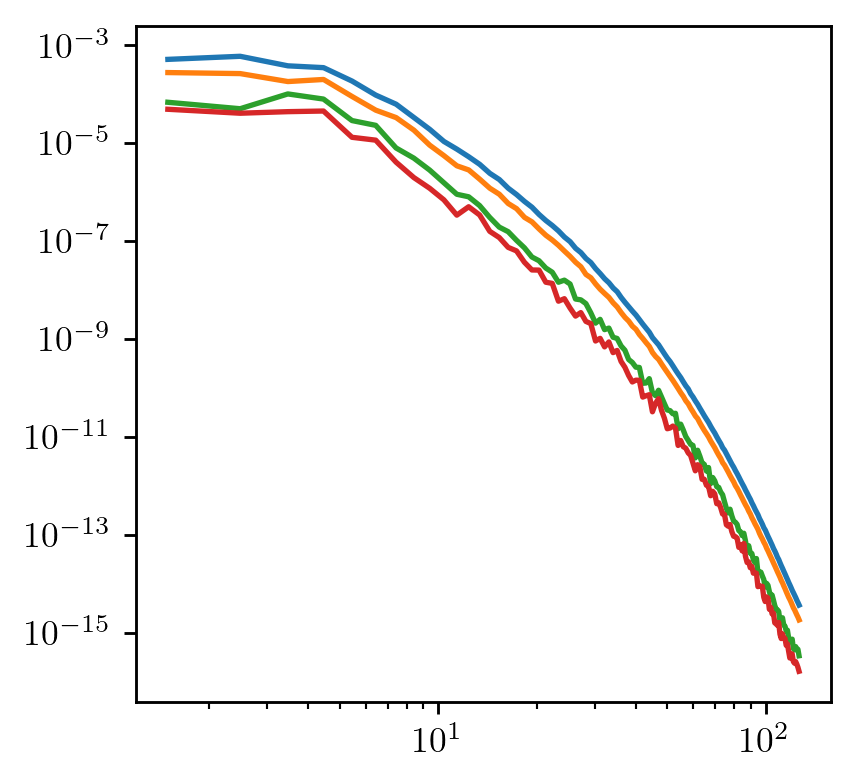

In [3]:
rho_spec = data.spectrum('rho')
_, _ = rho_spec.integrate()

rhod_spec = data.spectrum('rho_dephase')
_, _ = rhod_spec.integrate()

proj_rho_spec = data.spectrum('x3proj_rho')
_, _ = proj_rho_spec.integrate()

proj_rhod_spec = data.spectrum('x3proj_rho_dephase')
_, _ = proj_rhod_spec.integrate()


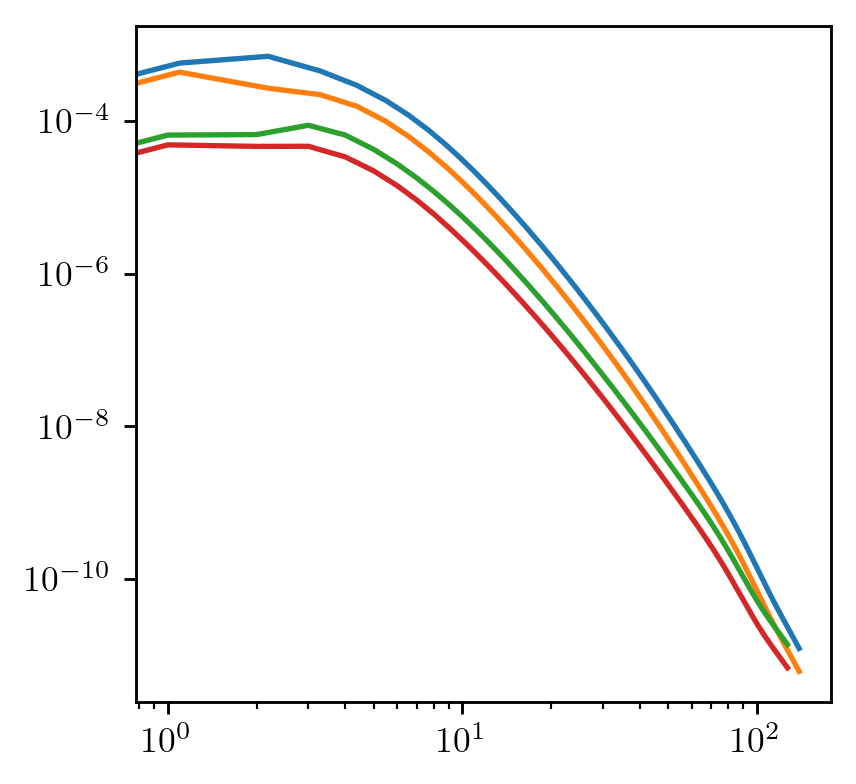

In [5]:
a_rho_spec = data.spectrum('rho', 'arevalo')

a_rhod_spec = data.spectrum('rho_dephase', 'arevalo')

a_proj_rho_spec = data.spectrum('x3proj_rho', 'arevalo')

a_proj_rhod_spec = data.spectrum('x3proj_rho_dephase', 'arevalo')


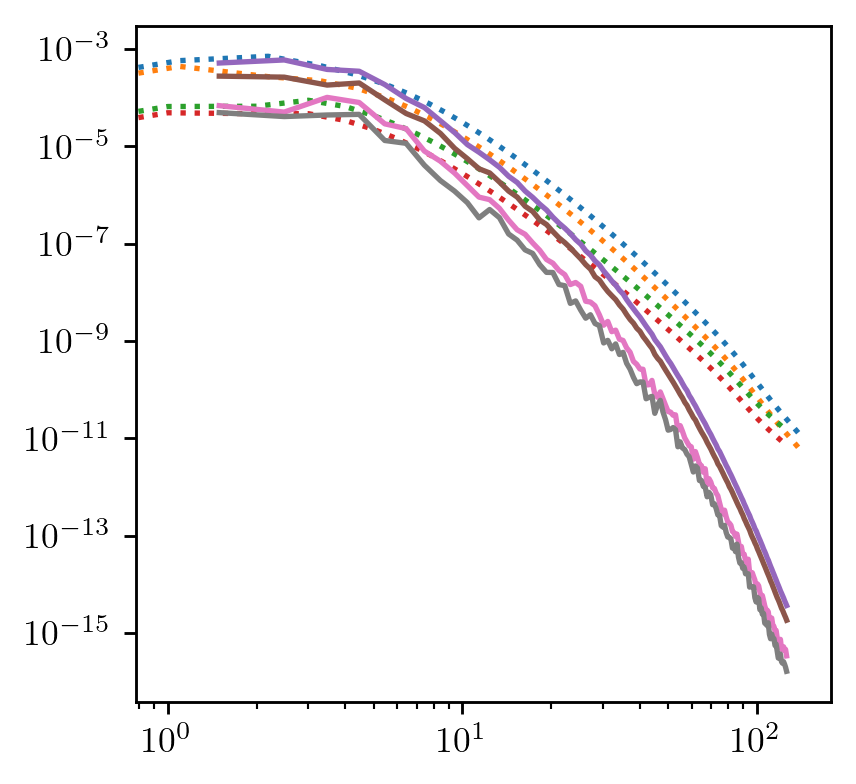

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

ax.loglog(a_rho_spec.modal_k, a_rho_spec.modal_fek, linestyle=':')
ax.loglog(a_rhod_spec.modal_k, a_rhod_spec.modal_fek, linestyle=':')

ax.loglog(a_proj_rho_spec.modal_k, a_proj_rho_spec.modal_fek, linestyle=':')
ax.loglog(a_proj_rhod_spec.modal_k, a_proj_rhod_spec.modal_fek, linestyle=':')

ax.loglog(rho_spec.modal_k, rho_spec.modal_fek)
ax.loglog(rhod_spec.modal_k, rhod_spec.modal_fek)

ax.loglog(proj_rho_spec.modal_k, proj_rho_spec.modal_fek)
ax.loglog(proj_rhod_spec.modal_k, proj_rhod_spec.modal_fek)